<a href="https://colab.research.google.com/github/tassegaetan1/colab-git-assignment2-UT/blob/main/Lesson_5_assignment_completed_executed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 5 Assignment - Titanic EDA

This notebook demonstrates data loading, cleaning, exploratory data analysis, multi-indexing, and visualisation using Pandas, Matplotlib, and Seaborn.

**Dataset:** Titanic-Dataset.csv


In [5]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')
sns.set_theme(style="whitegrid")

# Load the Titanic dataset from common notebook locations
possible_paths = [
    "/content/drive/MyDrive/Colab Notebooks/Titanic-Dataset.csv",
]

data_path = None
for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Titanic-Dataset.csv was not found. Upload it to Colab or place it in the working directory.")

df = pd.read_csv(data_path)
print(f"Dataset loaded successfully from: {data_path}")
print("Shape:", df.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully from: /content/drive/MyDrive/Colab Notebooks/Titanic-Dataset.csv
Shape: (891, 12)


## 1. Inspect the data

In [6]:

print("First 5 rows:")
display(df.head())

print("Last 5 rows:")
display(df.tail())

print("Data types:")
display(df.dtypes)

print("Summary statistics:")
display(df.describe(include='all'))


First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Last 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


Data types:


,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


Summary statistics:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


**Insight:**  
The dataset contains 891 passengers and 12 columns. Numerical columns such as `Age`, `Fare`, `SibSp`, and `Parch` will be useful for quantitative analysis, while categorical columns such as `Sex`, `Embarked`, and `Cabin` help explain survival patterns.


## 2. Clean and preprocess the data

In [7]:

# Create a working copy
df_clean = df.copy()

# New categorical feature for passenger class
class_map = {1: "First", 2: "Second", 3: "Third"}
df_clean["PclassCategory"] = df_clean["Pclass"].map(class_map)

# Create cabin category using the first letter; missing values become 'Unknown'
df_clean["CabinCategory"] = df_clean["Cabin"].fillna("Unknown").astype(str).str[0]
df_clean["CabinCategory"] = df_clean["CabinCategory"].replace({"U": "Unknown"})

# Handle missing Age values using the mean age
mean_age = df_clean["Age"].mean()
df_clean["Age"] = df_clean["Age"].fillna(mean_age)

# Create family size feature
df_clean["Family"] = df_clean["SibSp"] + df_clean["Parch"] + 1

print("Missing values after cleaning:")
display(df_clean.isnull().sum())

print("Preview of engineered features:")
display(df_clean[["Pclass", "PclassCategory", "Cabin", "CabinCategory", "Age", "Family"]].head(10))


Missing values after cleaning:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Preview of engineered features:


,Pclass,PclassCategory,Cabin,CabinCategory,Age,Family
0,3,Third,NaN,Unknown,22.000000,2
1,1,First,C85,C,38.000000,2
2,3,Third,NaN,Unknown,26.000000,1
3,1,First,C123,C,35.000000,2
4,3,Third,NaN,Unknown,35.000000,1
5,3,Third,NaN,Unknown,29.699118,1
6,1,First,E46,E,54.000000,1
7,3,Third,NaN,Unknown,2.000000,5
8,3,Third,NaN,Unknown,27.000000,3
9,2,Second,NaN,Unknown,14.000000,2


**Insight:**  
Missing values in `Age` were filled with the mean age so that analysis and visualisation would not fail. `PclassCategory`, `CabinCategory`, and `Family` were added to support richer analysis of passenger background and household size.


## 3. Identify specific data points

In [8]:

highest_fare = df_clean.loc[df_clean["Fare"].idxmax(), ["Name", "Fare", "Pclass", "Survived"]]
largest_family = df_clean.loc[df_clean["Family"].idxmax(), ["Name", "Family", "Pclass", "Survived"]]

print("Passenger with the highest fare:")
display(highest_fare.to_frame().T)

print("Passenger with the largest family size:")
display(largest_family.to_frame().T)


Passenger with the highest fare:


,Name,Fare,Pclass,Survived
258,"Ward, Miss. Anna",512.3292,1,1


Passenger with the largest family size:


,Name,Family,Pclass,Survived
159,"Sage, Master. Thomas Henry",11,3,0


## 4. Pandas Series and DataFrame functionalities

In [9]:

# Series example
ages_series = df_clean["Age"]
print("Age Series - first 5 values:")
display(ages_series.head())

# DataFrame subset
subset_df = df_clean[["Name", "Sex", "Age", "Fare"]]
print("Subset DataFrame:")
display(subset_df.head())

# Indexing and slicing
print("Indexing example - first passenger name:")
print(df_clean.loc[0, "Name"])

print("\nSlicing example - rows 0 to 4, selected columns:")
display(df_clean.loc[0:4, ["Name", "Sex", "Age", "Fare"]])


Age Series - first 5 values:


,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0


Subset DataFrame:


,Name,Sex,Age,Fare
0,"Braund, Mr. Owen Harris",male,22.0,7.2500
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833
2,"Heikkinen, Miss. Laina",female,26.0,7.9250
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000
4,"Allen, Mr. William Henry",male,35.0,8.0500


Indexing example - first passenger name:
Braund, Mr. Owen Harris

Slicing example - rows 0 to 4, selected columns:


,Name,Sex,Age,Fare
0,"Braund, Mr. Owen Harris",male,22.0,7.2500
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833
2,"Heikkinen, Miss. Laina",female,26.0,7.9250
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000
4,"Allen, Mr. William Henry",male,35.0,8.0500


## 5. Multi-indexing - survival rates by Sex and Pclass

In [10]:

survival_multi = df_clean.groupby(["Sex", "PclassCategory"])["Survived"].mean().to_frame("SurvivalRate")
survival_multi.index = pd.MultiIndex.from_tuples(survival_multi.index, names=["Sex", "PclassCategory"])

display(survival_multi)


SurvivalRate
Sex    PclassCategory              
female First               0.968085
       Second              0.921053
       Third               0.500000
male   First               0.368852
       Second              0.157407
       Third               0.135447

**Insight:**  
This multi-index table makes it easy to compare survival rates across two dimensions at once. Female passengers in higher classes generally had the highest survival rates, while male passengers in third class had the lowest.


## 6. Visualisations

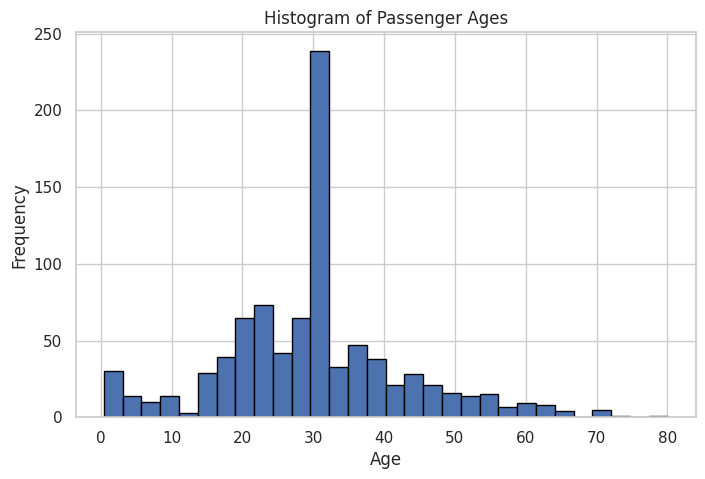

In [11]:

# Histogram of passenger ages
plt.figure(figsize=(8, 5))
plt.hist(df_clean["Age"], bins=30, edgecolor="black")
plt.title("Histogram of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


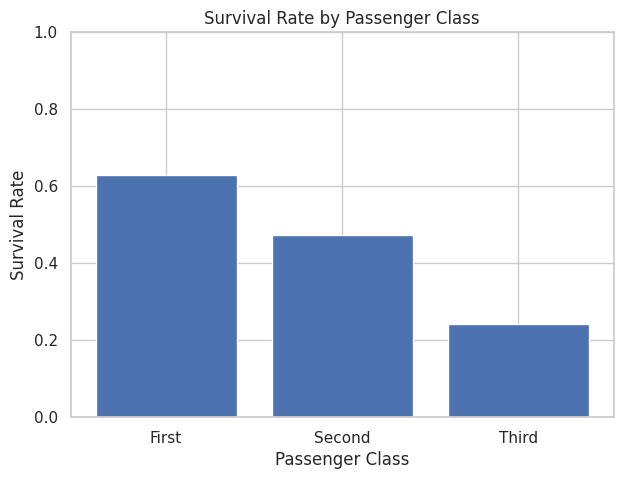

In [12]:

# Bar plot of survival rates by passenger class
survival_by_class = df_clean.groupby("PclassCategory")["Survived"].mean().reindex(["First", "Second", "Third"])

plt.figure(figsize=(7, 5))
plt.bar(survival_by_class.index, survival_by_class.values)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()


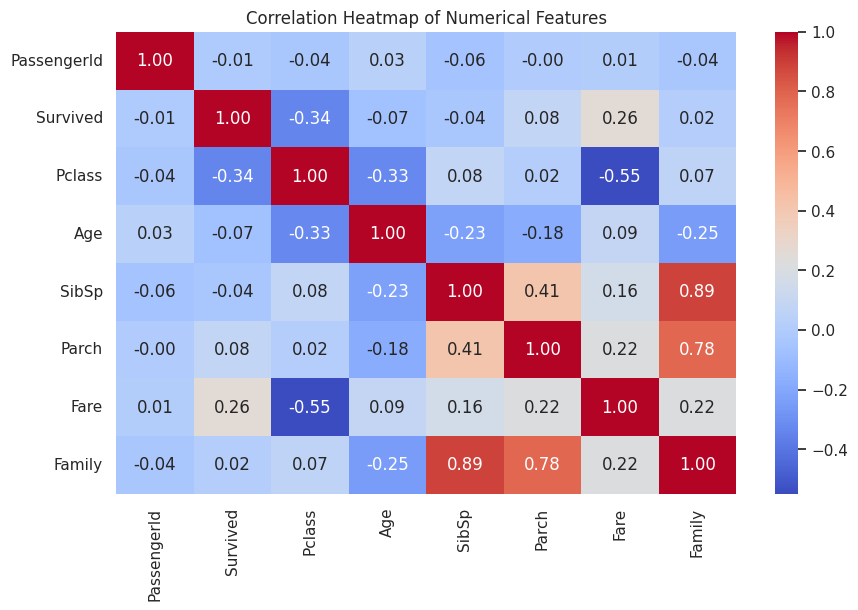

In [13]:

# Heatmap of correlations between numerical features
numeric_df = df_clean.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


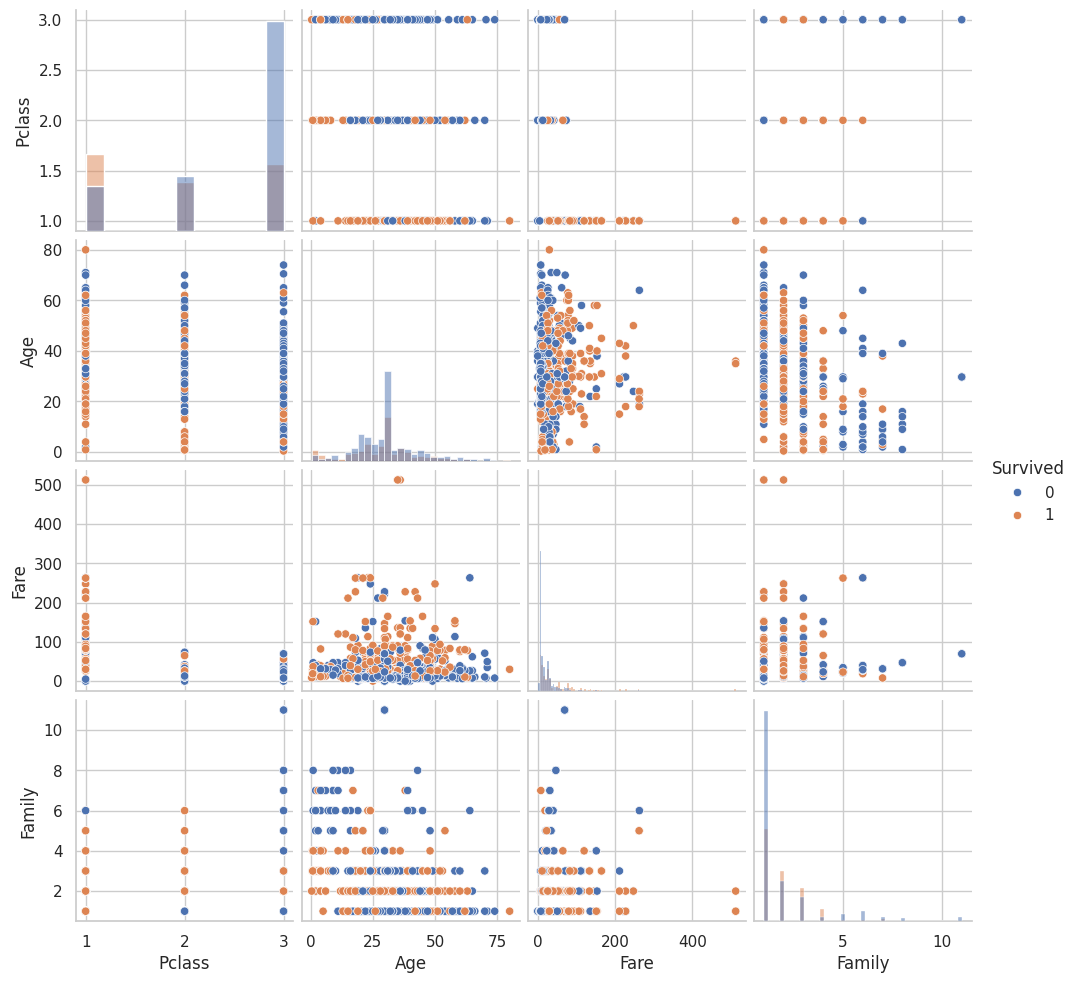

In [14]:

# Pair plot of selected features
selected_features = df_clean[["Survived", "Pclass", "Age", "Fare", "Family"]]
sns.pairplot(selected_features, hue="Survived", diag_kind="hist")
plt.show()


## 7. Survival rates by sex and passenger class

PclassCategory,First,Second,Third
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


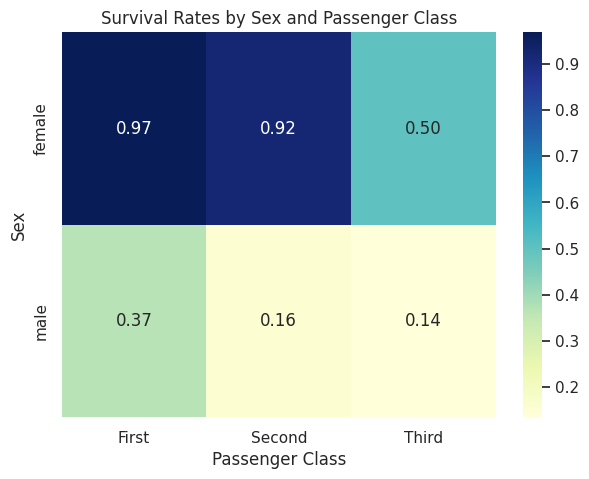

In [15]:

survival_table = pd.pivot_table(
    df_clean,
    values="Survived",
    index="Sex",
    columns="PclassCategory",
    aggfunc="mean"
)

display(survival_table)

plt.figure(figsize=(7, 5))
sns.heatmap(survival_table, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Survival Rates by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Sex")
plt.show()


**Insight:**  
Survival was strongly associated with both sex and class. Women had better survival rates than men in every class. First-class passengers also survived more often than second- and third-class passengers.


## 8. Age distribution using a box plot

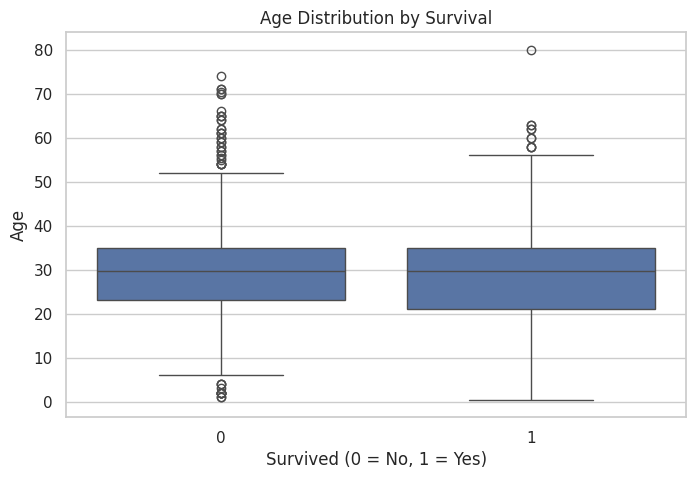

In [16]:

plt.figure(figsize=(8, 5))
sns.boxplot(x="Survived", y="Age", data=df_clean)
plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()


**Insight:**  
The box plot shows the spread of ages among survivors and non-survivors. Both groups contain children and older adults, but the presence of outliers suggests the Titanic had a wide age distribution.


## 9. Fare distribution using a violin plot

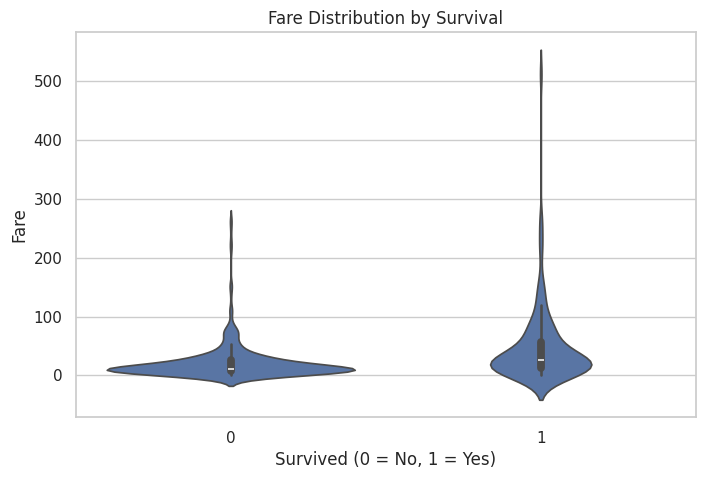

In [17]:

plt.figure(figsize=(8, 5))
sns.violinplot(x="Survived", y="Fare", data=df_clean)
plt.title("Fare Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")
plt.show()


**Insight:**  
Passengers who survived tended to have paid higher fares on average. This aligns with the earlier class analysis because higher fares were often associated with first-class travel.


## 10. Final EDA findings

In [18]:

print("Key Findings:")
print("1. Missing Age values were handled using the mean age.")
print("2. First-class passengers had the highest survival rate.")
print("3. Female passengers survived at much higher rates than male passengers.")
print("4. Passengers paying higher fares generally had better survival outcomes.")
print("5. Family size and passenger class provide additional context for survival behavior.")


Key Findings:
1. Missing Age values were handled using the mean age.
2. First-class passengers had the highest survival rate.
3. Female passengers survived at much higher rates than male passengers.
4. Passengers paying higher fares generally had better survival outcomes.
5. Family size and passenger class provide additional context for survival behavior.
